<a href="https://colab.research.google.com/github/tmtngu/AITUAN7NHOM/blob/main/5_M%E1%BB%87nh_Gi%C3%A1_Ti%E1%BB%81n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

duong_dan="/content/drive/MyDrive/AI NHÓM TUẦN 7/5 Mệnh Giá Tiền/Train"
chieu_dai_anh,chieu_cao_anh=224,224
kich_thuoc_goi=32

train=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='training',
    seed=123,
    crop_to_aspect_ratio=True)

menh_gia=train.class_names

test=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='validation',
    seed=123,
    crop_to_aspect_ratio=True)

chuan_hoa=tf.keras.layers.Rescaling(1./255)
toi_uu=tf.data.AUTOTUNE

train=train.map(lambda x,y:(chuan_hoa(x),y)).cache().shuffle(1000).prefetch(buffer_size=toi_uu)
test=test.map(lambda x,y:(chuan_hoa(x),y)).cache().prefetch(buffer_size=toi_uu)

Found 1472 files belonging to 5 classes.
Using 1178 files for training.
Found 1472 files belonging to 5 classes.
Using 294 files for validation.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt

so_menh_gia=5
model=Sequential()

model.add(RandomFlip("horizontal",input_shape=(chieu_dai_anh,chieu_cao_anh,3)))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))

model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(so_menh_gia, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,236,933 (50.49 MB)

 Trainable params: 13,235,973 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.6859 - loss: 1.3192 - val_accuracy: 0.1939 - val_loss: 2.5228
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.8913 - loss: 0.3074 - val_accuracy: 0.1939 - val_loss: 5.5100
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.9228 - loss: 0.2286 - val_accuracy: 0.1939 - val_loss: 8.4434
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.9363 - loss: 0.1879 - val_accuracy: 0.1939 - val_loss: 11.5100
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.9550 - loss: 0.1539 - val_accuracy: 0.1939 - val_loss: 11.5293
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.9610 - loss: 0.1307 - val_accuracy: 0.1939 - val_loss: 13.9997
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.9694 - loss: 0.0956 - val_accuracy: 0.1939 - val_loss: 13.3992
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.9525 - loss: 0.1175 - val_accuracy:

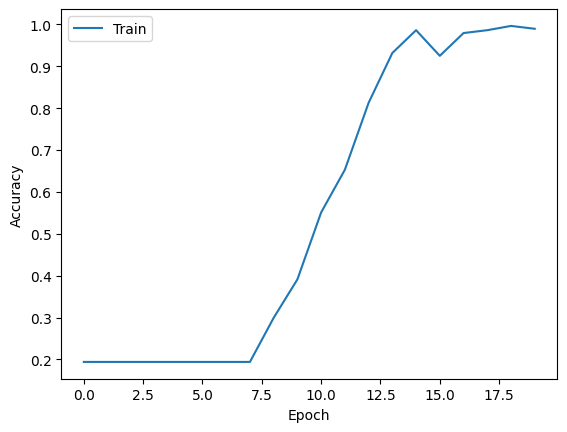

In [ ]:
history=model.fit(
    train,
    epochs=20,
    validation_data=test)
plt.plot(history.history['val_accuracy'],label='ket qua')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()
model.save("/content/filetrain5menhgiatientmt.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Đây là 100.000đ


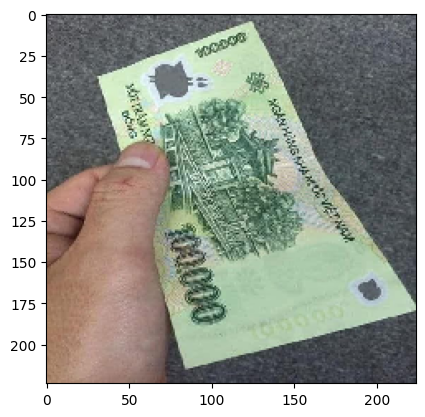

In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path="/content/100.jpg"
img=load_img(path,target_size=(chieu_dai_anh,chieu_cao_anh))
plt.imshow(img)
img=np.array(img)
img=img/255.0
img=img.reshape(1,chieu_dai_anh,chieu_cao_anh,3)

pred=np.argmax(model.predict(img))

ten=menh_gia[pred]
print(f"Đây là {ten}")